In [ ]:
.No  Name BITS ID Contribution
1.ADI SATHWIK 2024ab05213 100
2.AKASH PAREEK 2023ac05551 100
3.JAGADI SHRUTI CHANABASAPPA 2024aa05181 100
4.MAYANK NAYYAR 2024aa05716  100
5.R.DEEPIKA 2024aa05339  100

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import os

dataset_path = "/content/drive/MyDrive/Problem3_EuroSAT/EuroSAT"
print(os.listdir(dataset_path))


['SeaLake', 'HerbaceousVegetation', 'PermanentCrop', 'test.csv', 'validation.csv', 'label_map.json', 'train.csv', 'Forest', 'Highway', 'Industrial', 'Residential', 'Pasture', 'River', 'AnnualCrop']


In [6]:
urban_classes = ['Residential', 'Industrial']
natural_classes = ['Forest', 'Pasture', 'River']


In [7]:
# Basic utilities
import os
import cv2
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature extraction
from skimage.feature import local_binary_pattern, hog

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")


In [8]:
# Path to EuroSAT dataset in Google Drive
dataset_path = "/content/drive/MyDrive/Problem3_EuroSAT/EuroSAT"

# Define class groups
urban_classes = ['Residential', 'Industrial']
natural_classes = ['Forest', 'Pasture', 'River']

print("Urban classes:", urban_classes)
print("Natural classes:", natural_classes)


Urban classes: ['Residential', 'Industrial']
Natural classes: ['Forest', 'Pasture', 'River']


In [9]:
images = []
labels = []

IMAGE_SIZE = 128  # Resize to 128x128

def load_images(class_list, label):
    for cls in class_list:
        class_path = os.path.join(dataset_path, cls)
        for img_name in os.listdir(class_path)[:500]:  # limit to ~500 per class
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(img)
            labels.append(label)

# Load Urban = 1, Natural = 0
load_images(urban_classes, 1)
load_images(natural_classes, 0)

print("Total images loaded:", len(images))


Total images loaded: 2500


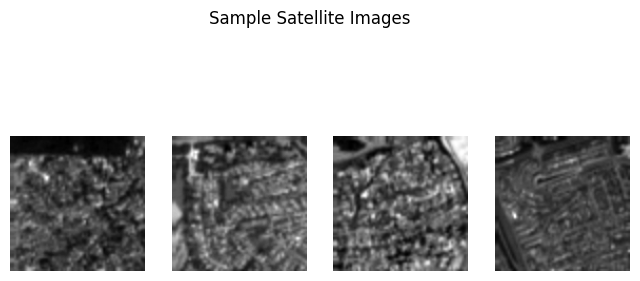

In [10]:
plt.figure(figsize=(8,4))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')
plt.suptitle("Sample Satellite Images")
plt.show()


In [11]:
def extract_lbp(img):
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
    return hist


In [12]:
def extract_hog(img):
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )
    return features


In [13]:
def extract_histogram(img):
    hist = cv2.calcHist([img], [0], None, [32], [0,256])
    return hist.flatten()


In [14]:
feature_vectors = []

for img in images:
    lbp_feat = extract_lbp(img)
    hog_feat = extract_hog(img)
    hist_feat = extract_histogram(img)

    combined = np.hstack([lbp_feat, hog_feat, hist_feat])
    feature_vectors.append(combined)

X = np.array(feature_vectors)
y = np.array(labels)

print("Feature vector shape:", X.shape)


Feature vector shape: (2500, 8142)


In [15]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Reduced feature shape:", X_pca.shape)


Reduced feature shape: (2500, 1291)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 2000
Testing samples: 500


In [17]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.986
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       312
           1       0.96      1.00      0.98       188

    accuracy                           0.99       500
   macro avg       0.98      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.948
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       312
           1       0.95      0.91      0.93       188

    accuracy                           0.95       500
   macro avg       0.95      0.94      0.94       500
weighted avg       0.95      0.95      0.95       500



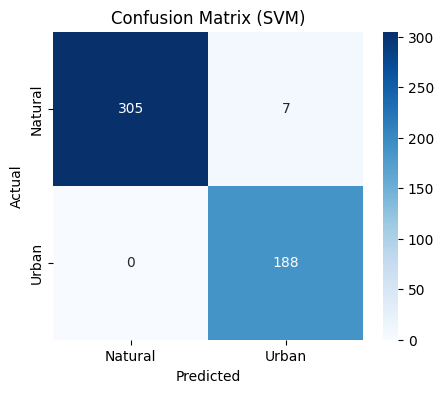

In [19]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Natural', 'Urban'],
            yticklabels=['Natural', 'Urban'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.show()


In [28]:
# Load external satellite image
external_img_path = "/content/drive/MyDrive/external_test.jpg"

img = cv2.imread(external_img_path)

if img is None:
    print(f"Error: Could not load image from {external_img_path}. Please check the path and file existence.")
else:
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    lbp = extract_lbp(img)
    hog_f = extract_hog(img)
    hist = extract_histogram(img)

    feature = np.hstack([lbp, hog_f, hist])
    feature = scaler.transform([feature])
    feature = pca.transform(feature)

    prediction = svm.predict(feature)

    print("Prediction:", "Urban" if prediction[0]==1 else "Natural")

Error: Could not load image from /content/drive/MyDrive/external_test.jpg. Please check the path and file existence.


In [29]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import os

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

external_img_path = "/content/drive/MyDrive/external_test.jpg"
# CHANGE path here if image is inside a folder

if not os.path.exists(external_img_path):
    print("❌ Image not found.")
    print("Files in MyDrive:", os.listdir("/content/drive/MyDrive"))
else:
    print("✅ Image found, processing...")

    ext_img = preprocess_image(external_img_path)

    if ext_img is not None:
        ext_features = np.hstack([
            extract_histogram(ext_img),
            extract_hog(ext_img),
            extract_lbp(ext_img)
        ])

        ext_features_scaled = scaler.transform([ext_features])
        ext_features_pca = pca.transform(ext_features_scaled)
        prediction = rf.predict(ext_features_pca)

        print("Predicted Class:",
              "Urban" if prediction[0] == 1 else "Natural")
    else:
        print("Error: Image could not be loaded for preprocessing.")

✅ Image found, processing...
Predicted Class: Natural
